# Предсказание калорийности блюд

**Описание задачи**<br>
Создать и обучить нейросеть, которая будет предсказывать калорийность блюд. Полученную модель можно интегрировать во многие fitness и health-приложения, она будет полезна тем, кто следит за своим здоровьем.

**Цель**<br>
Получить DL-модель, способную оценить калорийность блюда

**Целевая метрика**<br>
Модель будет считаться готовой к интеграции в продукт при точности оценки MAE < 50 (MAE — Mean Absolute Error) на тестовой выборке.

**Содержание:**

0. [Подготовка](#step_0)
1. [Разведочный анализ данных (EDA)](#step_1)
2. [Реализация пайплайна обучения](#step_2)
3. [Обучение модели](#step_3)
4. [Валидация качества](#step_4)
5. [Выводы](#step_5)

<a id='step_0'></a>
## 0. Подготовка

In [1]:
IS_KAGGLE = True

In [2]:
import sys
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import timm
import torch

from pathlib import Path
from PIL import Image
from IPython.display import display
from pprint import pprint

from transformers import AutoModel, AutoTokenizer

if IS_KAGGLE:
    sys.path.append('/kaggle/input/datasets/ruslanmushtakov/nutrition-dataset')
else:
    %load_ext autoreload
    %autoreload 2

from scripts.utils import (
    TrainingConfig, 
    train, 
    seed_everything, 
    plot_training_history,
    evaluate_best_model
)

Фиксируем ядро рандомизации, для повторения экспериментов.

In [3]:
RAND_SEED = 42
seed_everything(RAND_SEED)

Определяем необходимые пути (до данных, до моделей). 

In [4]:
if IS_KAGGLE:
    DATA_PATH = Path('/kaggle/input/datasets/ruslanmushtakov/nutrition-dataset/nutrition/data')
    OUTPUT_PATH = Path('/kaggle/working')
    MODELS_PATH = Path('/kaggle/working/models')
else:
    DATA_PATH = Path('./data/data')
    OUTPUT_PATH = Path('./output')
    MODELS_PATH = Path('./models')

<a id='step_1'></a>
## 1. Разведочный анализ данных (EDA)

**Задание:**<br>
1. Загрузите датасет и визуализируйте часть данных. Изучите то, с чем предстоит работать.
2. Сформируйте видение:
    * как вы будете решать задачу,
    * какие подходы к обогащению/аугментации данных примените и почему,
    * на какие метрики будете ориентироваться при обучении.

In [5]:
ingredients_path = DATA_PATH / 'ingredients.csv'
dish_path = DATA_PATH / 'dish.csv'
images_dir = DATA_PATH / 'images'

Посмотрим подробно на таблицу с ингредиентами.

In [6]:
ingredients_df = pd.read_csv(ingredients_path)

print(f'Размер ingredients_df: {ingredients_df.shape}')
print('-'*60)

ingredients_df.info()
print('-'*60)

display(ingredients_df.head())

Размер ingredients_df: (555, 2)
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555 entries, 0 to 554
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      555 non-null    int64 
 1   ingr    555 non-null    object
dtypes: int64(1), object(1)
memory usage: 8.8+ KB
------------------------------------------------------------


,id,ingr
0,1,cottage cheese
1,2,strawberries
2,3,garden salad
3,4,bacon
4,5,potatoes


555 ингредиентов. Пропусков в таблице нет - дополнительная предобработка не нужна.

Посмотрим подробно на таблицу с блюдами.

In [7]:
dish_df = pd.read_csv(dish_path)

print(f'Размер dish_df: {dish_df.shape}')
print('-'*60)

dish_df.info()
print('-'*60)

display(dish_df.head())

Размер dish_df: (3262, 5)
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3262 entries, 0 to 3261
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dish_id         3262 non-null   object 
 1   total_calories  3262 non-null   float64
 2   total_mass      3262 non-null   float64
 3   ingredients     3262 non-null   object 
 4   split           3262 non-null   object 
dtypes: float64(2), object(3)
memory usage: 127.6+ KB
------------------------------------------------------------


,dish_id,total_calories,total_mass,ingredients,split
0,dish_1561662216,300.794281,193.0,ingr_0000000508;ingr_0000000122;ingr_000000002...,test
1,dish_1561662054,419.438782,292.0,ingr_0000000312;ingr_0000000026;ingr_000000002...,train
2,dish_1562008979,382.936646,290.0,ingr_0000000448;ingr_0000000520;ingr_000000046...,test
3,dish_1560455030,20.590000,103.0,ingr_0000000471;ingr_0000000031;ingr_0000000347,train
4,dish_1558372433,74.360001,143.0,ingr_0000000453,train


3262 блюда. Пропусков нет, типы данных для колонок корректные - дополнительная предобработка не нужна.<br>
Проверим корректность разделения на train и test.

In [8]:
dish_df['split'].value_counts(normalize=True)

split
train    0.844574
test     0.155426
Name: proportion, dtype: float64

Соотношение корректное - на 85% датасета обучаемся, на 15% проверяем.

Обработаем имеющиеся данные - соберем все в один датафрейм, добавим полезные колонки.

In [9]:
# сохраним оригинальную таблицу с блюдами
dish_orig_df = dish_df.copy()

In [10]:
# обработаем список ингридиентов в блюдах
ingredients_dict = (
    ingredients_df
    .assign(ingredient_id=lambda df: 'ingr_' + df['id'].astype(str).str.zfill(10))
    .set_index('ingredient_id')['ingr']
    .to_dict()
)

dish_df['ingredient_ids'] = dish_df['ingredients'].str.split(';')
dish_df['ingredient_count'] = dish_df['ingredient_ids'].apply(len)
dish_df['ingredient_names'] = dish_df['ingredient_ids'].apply(
    lambda ids: [ingredients_dict.get(ingredient_id, ingredient_id) 
                 for ingredient_id in ids if ingredient_id]
)
dish_df['ingredients_text'] = dish_df['ingredient_names'].apply(', '.join)

# обработаем изображения блюд
dish_df['image_path'] = dish_df['dish_id'].apply(lambda dish_id: images_dir / dish_id / 'rgb.png')
dish_df['has_image'] = dish_df['image_path'].apply(lambda path: path.exists())

# посмотрим на полученные данные без лишних колонок
dish_text_df = dish_df[
    ['dish_id', 'split', 'total_calories', 'total_mass', 'ingredient_count', 'ingredients_text']
].copy()

display(dish_text_df.head(10))

,dish_id,split,total_calories,total_mass,ingredient_count,ingredients_text
0,dish_1561662216,test,300.794281,193.0,17,"soy sauce, garlic, white rice, parsley, onions..."
1,dish_1561662054,train,419.438782,292.0,17,"pepper, white rice, mixed greens, garlic, soy ..."
2,dish_1562008979,test,382.936646,290.0,13,"jalapenos, lemon juice, pork, wheat berry, cab..."
3,dish_1560455030,train,20.590000,103.0,3,"cherry tomatoes, cucumbers, baby carrots"
4,dish_1558372433,train,74.360001,143.0,1,deprecated
5,dish_1565640549,train,45.482903,139.0,14,"tomatoes, cilantro, olive oil, mustard greens,..."
6,dish_1563207364,train,309.269989,271.0,6,"scrambled eggs, yam, grapes, egg whites, olive..."
7,dish_1561575474,train,120.058434,183.0,5,"salt, eggplant, roasted potatoes, cauliflower,..."
8,dish_1563216717,train,246.007996,332.0,12,"garlic, squash, cherry tomatoes, chicken breas..."
9,dish_1565972591,train,195.199997,122.0,1,chicken apple sausage


Краткое резюме по всем данным.

In [11]:
summary_df = pd.DataFrame({
    'metric': ['total_dishes', 'train_samples', 'test_samples', 'unique_ingredients', 'missing_images'],
    'value': [
        len(dish_df),
        int((dish_df['split'] == 'train').sum()),
        int((dish_df['split'] == 'test').sum()),
        ingredients_df['id'].nunique(),
        int((~dish_df['has_image']).sum()),
    ],
})
display(summary_df)

,metric,value
0,total_dishes,3262
1,train_samples,2755
2,test_samples,507
3,unique_ingredients,555
4,missing_images,0


Важно, что у нас для всех блюд есть их изображения.

Посмтрим на адекватность распределения количества калорий и количестов ингрединтов в блюдах.

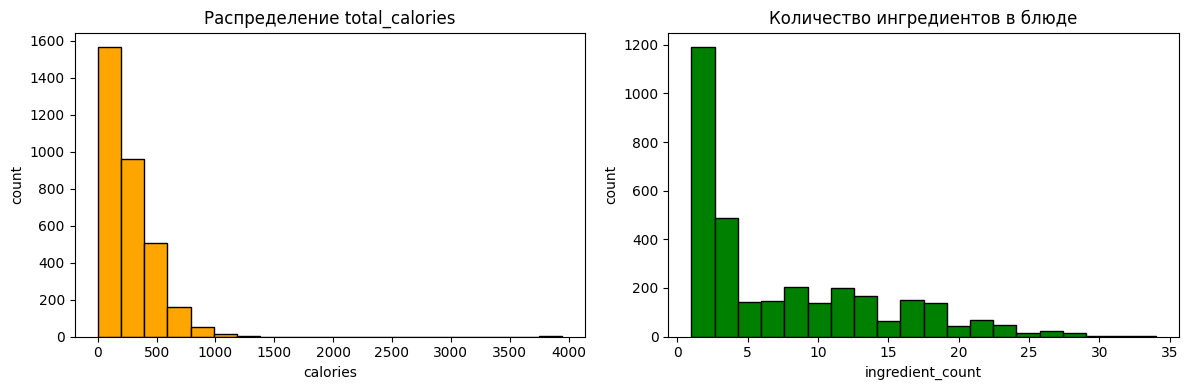

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(dish_df['total_calories'], bins=20, color='orange', edgecolor='black')
axes[0].set_title('Распределение total_calories')
axes[0].set_xlabel('calories')
axes[0].set_ylabel('count')

axes[1].hist(dish_df['ingredient_count'], bins=20, color='green', edgecolor='black')
axes[1].set_title('Количество ингредиентов в блюде')
axes[1].set_xlabel('ingredient_count')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.show()

Все корректно.
- Калорийность:
    - подавляющее число блюд имеют калораж до 500 калорий - адекватное значение;
    - нет блюд с отрицательное калорийностью;
    - есть блюда в районе 4000 калорий, такое тоже в принципе может быть;
    - дополнительно что-то отбрасывать из таблицы по данному показателю __не__ надо.
- Количество ингредиентов:
    - преобладают простые блюда - до 5 ингредиентов;
    - есть что-то сложноприготовленное. Максимальное значение в районе 30-35 игредиентов. Такое себе тоже можно предстваить;
    - дополнительно что-то отбрасывать из таблицы по данному показателю __не__ надо.

Посмотрим глазами на случайные блюда. Проверим адекватность проставленной калорийности, массы и количества ингредиентов.

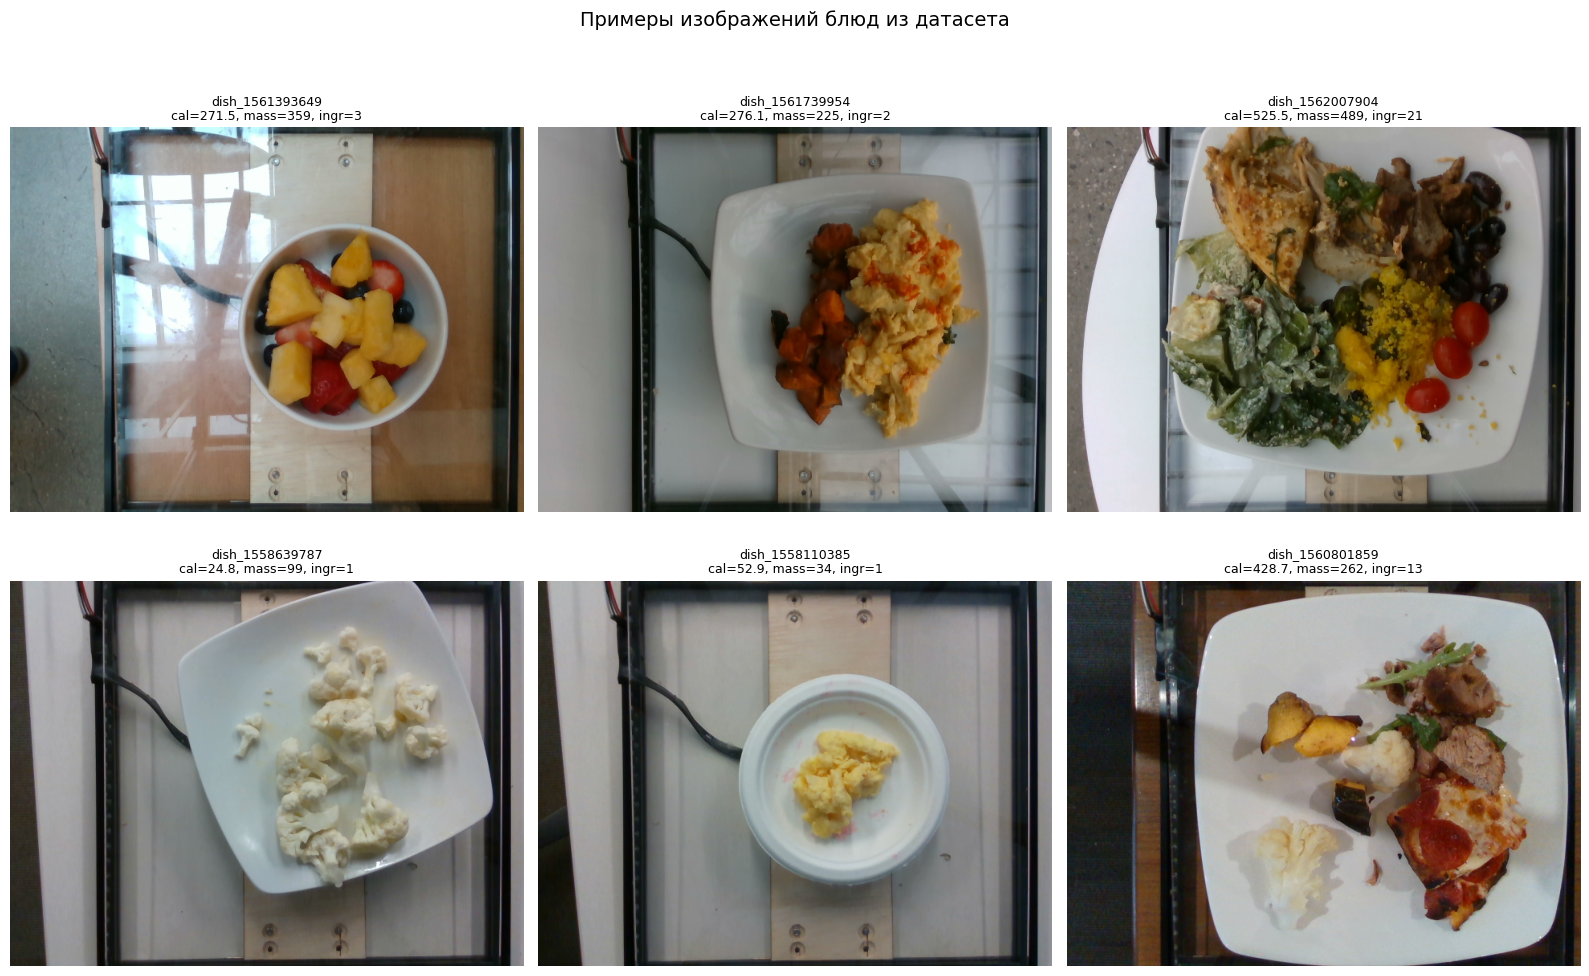

In [13]:
sample_df = dish_df.sample(6, random_state=RAND_SEED).reset_index(drop=True)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, row in zip(axes.flat, sample_df.to_dict('records')):
    with Image.open(row['image_path']) as img:
        ax.imshow(img)

    ax.set_title(
        f"{row['dish_id']}\ncal={row['total_calories']:.1f}, mass={row['total_mass']:.0f}, ingr={row['ingredient_count']}",
        fontsize=9,
    )
    ax.axis('off')

plt.suptitle('Примеры изображений блюд из датасета', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Изображения соответсвуют описаниям, значения характеристик адекваны.

**Выводы по этапу**<br>
1. Загрузили датачет, изучили данные, вывели изображения блюд, проверили на адекватность соответствие характеристик блюд.
2. Видение решения задачи
    - *Как будем решать задачу*<br>
    Будем решать задачу мультимодальной регрессии: на вход модель получает изображение блюда и текстовое описание его ингредиентов, а на выходе предсказывает калорийность этого блюда. Возьмем предобученную модель для изображений и текстовый энкодер для списка ингредиетнтов. После объединеним полученные признаки в общей регрессионной голове. Также нужно будет дополнительно использовать признак `total_mass` (масса блюда), т.к. он напрямую связан с калорийностью.
    - *Какие подходы к обогащению и аугментации данных применим*<br>
    Для изображений стоит взять умеренные аугментации, которые сохраняют содержание блюда: небольшие повороты, горизонтальные отражения, умеренное изменение яркости и контраста. Такие преобразования помогут модели лучше обобщать на разные условия съемки и освещения. Более агресивные аугментации применять не стоит, потому что визуальный объем и структура бюлд напрямую влияют на оценку калорийности.
    Для текста аугментацию применять первоначально не планируем - список ингредиентов уже достаточно структурирован.
    - *На какие метрики будем ориентироваться при обучении*<br>
    Основная метрика по ТЗ - `MAE`. Именно по ней будем выбирать лучшую модель и оценивать итоговое качество. Ориентир — добиться `MAE < 50` на тестовой выборке.

<a id='step_2'></a>
## 2. Реализация пайплайна обучения

**Задание:**<br>
1. Используя .py-файлы для сохранения кода, реализуйте:
    * Загрузчики данных и датасеты.
    * Опциональный код предобработки/аугментации данных.
    * Код обучения и валидации для импортирования в виде одной функции (train).
    * Конфиг-файл для запуска модели и сохранения результатов обучения.
    * Код для получения воспроизводимых результатов (seed) с выводом метрик.

In [14]:
# text_model = AutoModel.from_pretrained(cfg.TEXT_MODEL_NAME)
# print(text_model)

In [15]:
# image_model = timm.create_model('tf_efficientnetv2_s', pretrained=True, num_classes=0)
# print(image_model)

In [16]:
config = TrainingConfig(
    RUN_NAME = 'multimodal_regression',

    # TEXT_MODEL_NAME = 'distilbert-base-uncased',
    TEXT_MODEL_NAME = 'bert-base-uncased',
    # IMAGE_MODEL_NAME = 'resnet50',
    IMAGE_MODEL_NAME = 'tf_efficientnetv2_m',

    # TEXT_MODEL_UNFREEZE = 'transformer.layer.4|transformer.layer.5',
    TEXT_MODEL_UNFREEZE = 'encoder.layer.11|pooler',
    # IMAGE_MODEL_UNFREEZE = 'layer3|layer4',
    IMAGE_MODEL_UNFREEZE = 'blocks.6|conv_head|bn2',

    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu',
    PIN_MEMORY = torch.cuda.is_available(),
    NUM_WORKERS = 4,

    SEED = RAND_SEED,

    EPOCHS = 50,
    BATCH_SIZE = 16,
    MAX_TEXT_LENGTH = 128,

    HIDDEN_DIM = 512,
    DROPOUT = 0.3,
    TEXT_LR = 5e-5,
    IMAGE_LR = 5e-5,
    WEIGHT_DECAY = 5e-4,

    SCHEDULER_FACTOR = 0.8,
    SCHEDULER_PATIENCE = 4,
    SCHEDULER_MIN_LR = 1e-6,

    LOSS_NAME = 'smooth_l1',

    DATA_PATH = str(DATA_PATH),
    OUTPUT_PATH = str(OUTPUT_PATH),
    MODELS_PATH = str(MODELS_PATH),
)
pprint(config)

TrainingConfig(RUN_NAME='multimodal_regression',
               TEXT_MODEL_NAME='bert-base-uncased',
               IMAGE_MODEL_NAME='tf_efficientnetv2_m',
               TEXT_MODEL_UNFREEZE='encoder.layer.11|pooler',
               IMAGE_MODEL_UNFREEZE='blocks.6|conv_head|bn2',
               IMAGE_COLUMN='image_path',
               TEXT_COLUMN='ingredients_text',
               MASS_COLUMN='total_mass',
               INGREDIENT_COUNT_COLUMN='ingredient_count',
               TARGET_COLUMN='total_calories',
               USE_MASS_FEATURE=True,
               USE_INGREDIENT_COUNT_FEATURE=True,
               DEVICE='cuda',
               NUM_WORKERS=4,
               PIN_MEMORY=True,
               SEED=42,
               EPOCHS=50,
               BATCH_SIZE=16,
               MAX_TEXT_LENGTH=128,
               HIDDEN_DIM=512,
               DROPOUT=0.3,
               TEXT_LR=5e-05,
               IMAGE_LR=5e-05,
               HEAD_LR=0.0001,
               WEIGHT_DECAY=0.0005,
 

**Выводы по этапу**<br>
Весь необходимый функционал реализован в сопутсвующих .py-файлах
* Загрузчики данных и датасеты (dataset.py: `create_datasets`, `create_dataloaders`)
* Опциональный код предобработки/аугментации данных (dataset.py: `get_transforms`)
* Код обучения и валидации для импортирования в виде одной функции (utils.py: `train`, `validate`)
* Конфиг-файл для запуска модели и сохранения результатов обучения (utils.py: `TrainingConfig`)
* Код для получения воспроизводимых результатов (seed) с выводом метрик (utils.py: `seed_everything`)

<a id='step_3'></a>
## 3. Обучение модели

**Задание:**<br>
1. Выполните обучение модели на предоставленной ВМ с использованием кода с этапа 2.

In [17]:
train_result = train(config, dish_df, config.DEVICE)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

...

Epoch 48/50 | train_loss=26.8719 | train_mae=27.1940 | val_loss=54.9768 | val_mae=55.7728 | current_lrs=[2.0480000000000007e-05, 2.0480000000000007e-05, 4.0960000000000014e-05]


 98%|█████████▊| 49/50 [1:08:34<01:23, 83.67s/it]

Epoch 49/50 | train_loss=27.2915 | train_mae=27.8648 | val_loss=58.2166 | val_mae=59.0595 | current_lrs=[2.0480000000000007e-05, 2.0480000000000007e-05, 4.0960000000000014e-05]


100%|██████████| 50/50 [1:09:57<00:00, 83.96s/it]

Epoch 50/50 | train_loss=27.1412 | train_mae=27.7290 | val_loss=54.0162 | val_mae=54.7688 | current_lrs=[2.0480000000000007e-05, 2.0480000000000007e-05, 4.0960000000000014e-05]


In [18]:
print(f"best_val_mae: {train_result['best_val_mae']}")
print(f"best_checkpoint_path: {train_result['best_checkpoint_path']}")
print(f"history_path: {train_result['history_path']}")

best_val_mae: 53.591461181640625
best_checkpoint_path: /kaggle/working/models/multimodal_regression/best_model.pt
history_path: /kaggle/working/models/multimodal_regression/train_history.json


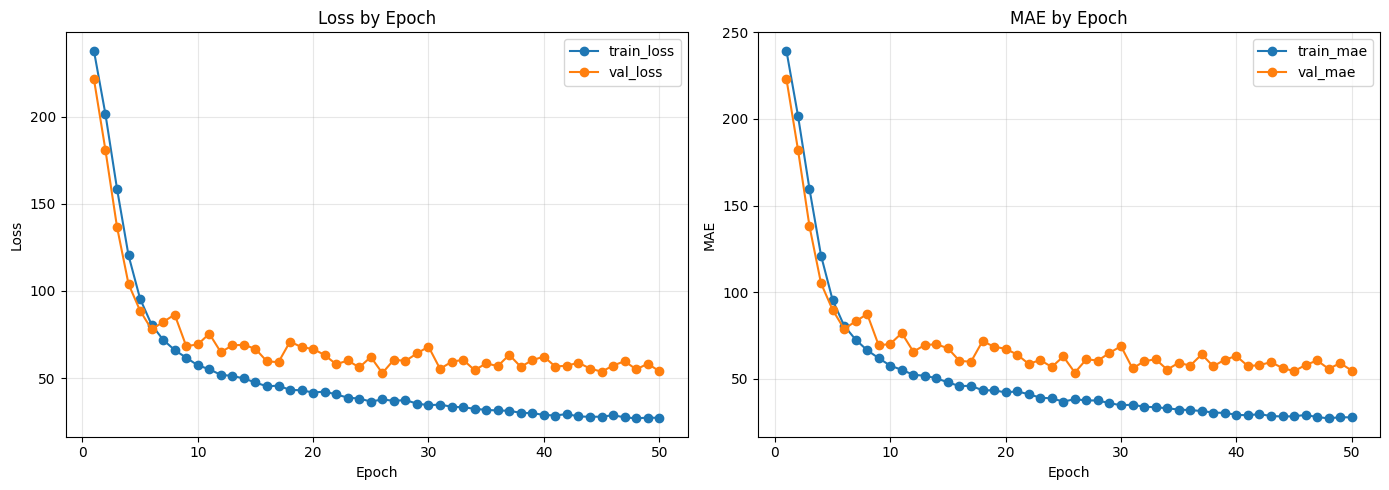

(<Figure size 1400x500 with 2 Axes>,
 array([<Axes: title={'center': 'Loss by Epoch'}, xlabel='Epoch', ylabel='Loss'>,
        <Axes: title={'center': 'MAE by Epoch'}, xlabel='Epoch', ylabel='MAE'>],
       dtype=object))

In [19]:
plot_training_history(train_result['history'])

**Выводы по этапу**<br>
Обучение выполнено. Сохранена модель, которая показала лучшее качество, а также вся история обучения. Построены графики изменений функции потерь и функции качества по эпохам.

<a id='step_4'></a>
## 4. Валидация качества

**Задание:**<br>
1. Запустите модель на тестовом сплите данных test и выведите финальную целевую метрику по модели.
2. Выведите топ-5 блюд, по которым оценка модели наименее точна. Опишите возможные причины низкого качества на этих примерах.

In [20]:
test_result = evaluate_best_model(config, dish_df, config.DEVICE)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Test loss: 52.8468
Test MAE: 53.5915


In [21]:
test_predictions_df = test_result['predictions_df']
test_predictions_df = test_predictions_df.merge(dish_df, on='dish_id', how='left')
test_predictions_df = test_predictions_df.sort_values(
        by='absolute_error',
        ascending=False,
    ).reset_index(drop=True)

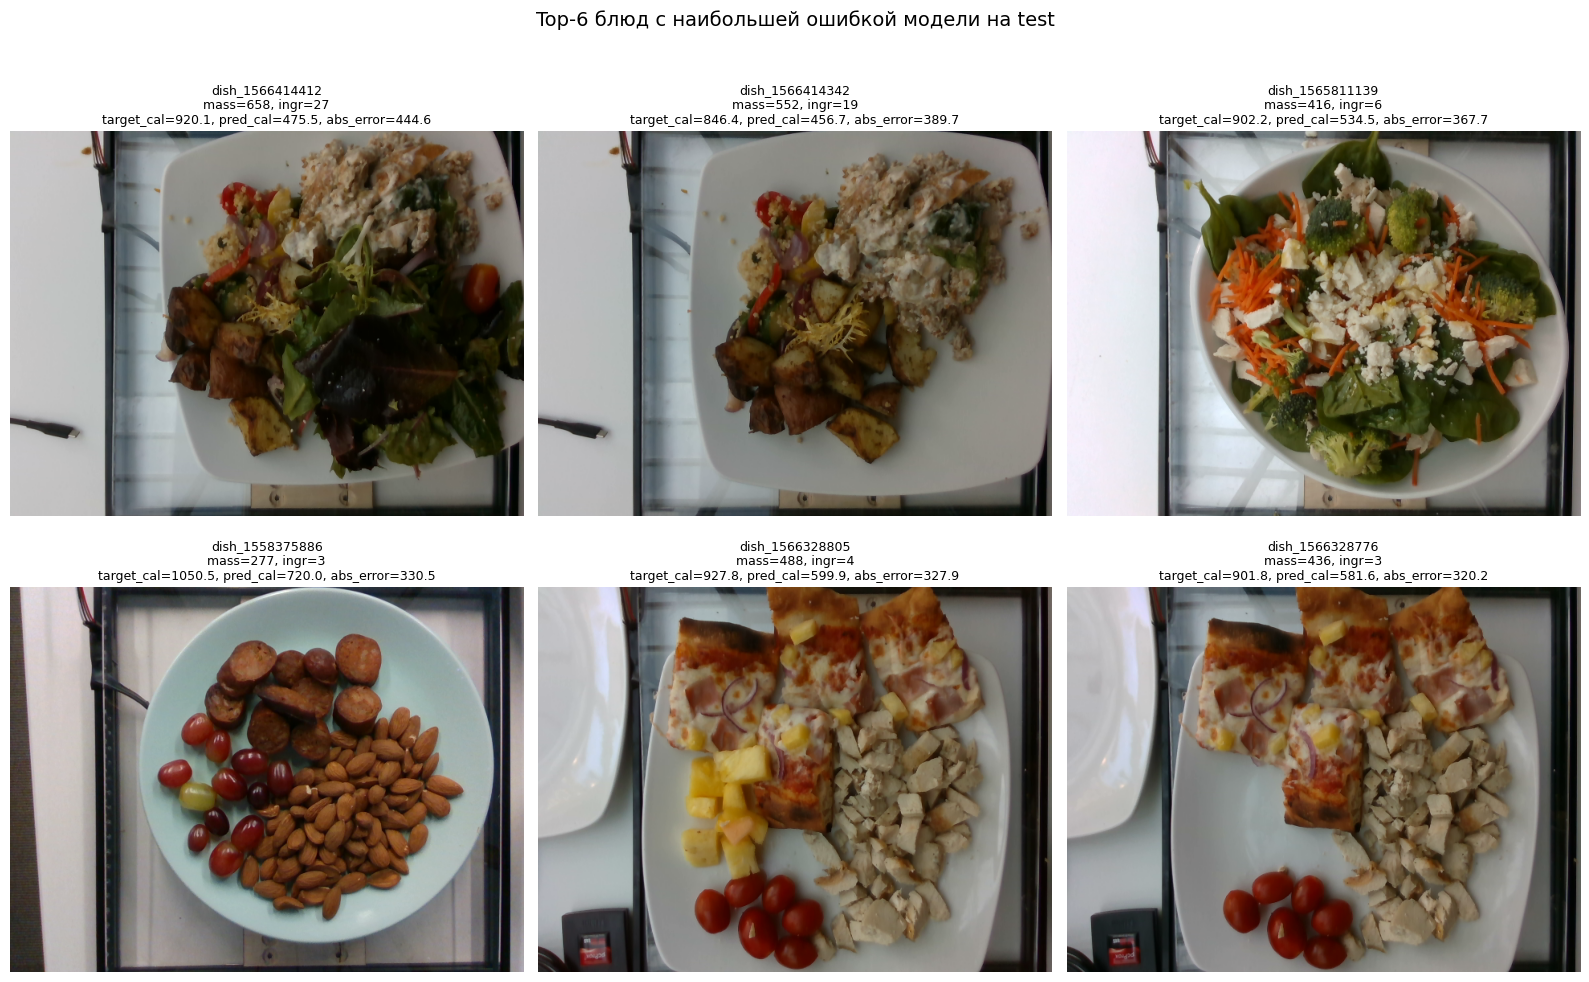

In [22]:
worst_examples_df = test_predictions_df.head(6).copy()
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, row in zip(axes.flat, worst_examples_df.to_dict('records')):
    with Image.open(row['image_path']) as img:
        ax.imshow(img)

    ax.set_title(
        f"{row['dish_id']}\nmass={row['total_mass']:.0f}, ingr={row['ingredient_count']}\n" + 
        f"target_cal={row['target']:.1f}, pred_cal={row['prediction']:.1f}, abs_error={row['absolute_error']:.1f}",
        fontsize=9,
    )
    ax.axis('off')

plt.suptitle('Top-6 блюд с наибольшей ошибкой модели на test', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**Выводы по этапу**<br>
1. На тестовом датасете запущена лучшая модель с обучения. Выведена целевая метрика по модели.
2. Выведены топ-6 блюд (для красоты), по которым оценка модели наименее точна.<br>
    * Видно что модель ошибается в меньшую стороны - предсказывает меньше калорий, чем есть на самом деле.<br>
    * В основном это происходит в многосоставных блюдах, где ингредиенты сильно перемешаны. В таком случае, довольно тяжело посчитать калорийность отдельных ингредиентов - они распределен по всему блюду, и общее количество каждого непонятно.<br>
    * В блюдах есть составляющие, которые идут за один ингредиент, а на самом деле они сложносоставные (например, пицца). Модели видимо сложно визуально понять, когда считать для составляющей калорийность раздельно, а когда вместе
    * Также видно, что существует проблема с орехами. Видимо, это особенность имено этого продукта. Модель не научилась определять, что есть такие продукты, которые весят мало, занимают сравнительно немного места, но очень калорийные. К таким как раз можно отнечти орехи.

<a id='step_5'></a>
## 5. Выводы

В проекте реализован полный мультимодальный pipeline для предсказания калорийности блюд по изображению и составу ингредиентов. Проведён EDA, подготовлены датасеты и загрузчики, реализованы воспроизводимое обучение, валидация и инференс сохранённой модели. В качестве решения выбрана мультимодальная регрессионная модель, объединяющая визуальные, текстовые и числовые признаки. Текущая лучшая конфигурация показывает MAE ≈ 53.6 на тестовом наборе, что подтверждает работоспособность подхода, но пока не достигает целевого требования ТЗ MAE < 50.